<center>
    <h1></h1>
    <h1><b>OCES 5303</b></h1>
    <h2>Extended Project</h2>
    <hr>
    <p>Jonas Mathisrud Sterud</p>
    <p>21335836</p>
</center>

<center>
    <h1></h1>
    <h3><i>Abstract</i></h3>
    <p>
    ...
    </p>
    <img src="./figures/cover.jpg" width="50%">
</center>

## Configuration

In [58]:
## Imports

import numpy as np
import pandas as pd
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
import torch
import cv2
import pickle
import random
import os

from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer, SplineTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error, r2_score
from datetime import datetime

from torch import nn
from skorch import NeuralNetRegressor

## Configuration

seed = int(11111)
_ = random.seed(seed)
_ = np.random.seed(seed)
_ = torch.manual_seed(seed)
_ = torch.backends.cudnn.deterministic = True
_ = torch.backends.cudnn.benchmark = False

## Colors

RED = "#FF6200"
RED_TRANSPARENT = "#FF6200A7"
GREEN = "#00B755"
GREEN_TRANSPARENT = "#00B755A7"
BLUE = "#0048FF"
BLUE_TRANSPARENT = "#0048FFA7"
GREY = "#959595"
GREY_TRANSPARENT = "#959595A7"


<h1>The Data</h1>

<p>

</p>

In [2]:
TRAIN_PNG_DIR = "./data/TRAIN_png/TRAIN_png"
TEST_PNG_DIR = "./data/TEST_png/TEST_png"
LABELS_TRAIN_DIR = "./data/LABELS_TRAIN/train"
TRAIN_IMAGES_PKL_DIR = "./data/train_images_pkl"
TEST_IMAGES_PKL_DIR = "./data/test_images_pkl"

# Load PKLs

def load_pkl(directory: str) -> dict:
    out = {}

    with os.scandir(directory) as dirs:
        for dir in dirs:
            date = datetime.strptime(dir.path.split("/")[-1], "%Y%m%d")

            out[date] = {}
            with os.scandir(dir) as files:
                for file in files:
                    if file.is_file():
                        name = file.path.split("/")[-1].removesuffix(".pkl")
                        if (name == "eddy_centre"): # Only Eddy centres for now
                            with open(file.path, "rb") as rb_file:
                                try:
                                    data = pickle.load(rb_file)
                                    out[date][name] = data
                                except Exception as e:
                                    print(e)
    
    return out

# Load labels
def load_labels(directory: str) -> dict:
    out = {}

    with os.scandir(directory) as files:
        for file in files:
            date = datetime.strptime(file.path.split("_")[-1].removesuffix(".csv"), "%Y%m%d")
            labels = pd.read_csv(file.path, header=None)

            out[date] = labels

    return out

# Load PNGs

def load_pngs(directory: str) -> pd.DataFrame:
    out = {}

    with os.scandir(directory) as files:
        for file in files:
            if file.is_file:
                (category, date, number) = file.path.split("/")[-1].removesuffix(".png").split("_")
                category = category
                date = datetime.strptime(date, "%Y%m%d")
                number = int(number)

                if out.get(category) == None:
                    out[category] = {}

                if out[category].get(date) == None:
                    out[category][date] = {}

                out[category][date][number] = cv2.imread(file.path, cv2.IMREAD_GRAYSCALE)

    for category in out.keys():
        for date in out[category].keys():
            out[category][date] = list(map(lambda kv: kv[1], sorted(out[category][date].items())))

    return pd.DataFrame(out)

# Load

df_png_train = load_pngs(TRAIN_PNG_DIR)
df_png_test = load_pngs(TEST_PNG_DIR)

train_pkl_mapping = load_pkl(TRAIN_IMAGES_PKL_DIR)
labels_mapping = load_labels(LABELS_TRAIN_DIR)

# Format Eddy centres, labels

df_eddy_centre = pd.DataFrame(map(lambda kv: (kv[0], kv[1]["eddy_centre"]), train_pkl_mapping.items())).set_index(0).rename(columns={ 1 : "EDDY_CENTRE"})
df_labels = pd.DataFrame(map(lambda kv: (kv[0], kv[1].values), labels_mapping.items())).set_index(0).rename(columns={ 1: "TRAIN_LABELS"})

# Combine
df_train = pd.concat([df_png_train, df_eddy_centre, df_labels], axis=1, sort=False)
df_test = pd.concat([df_png_test], axis=1, sort=False)

In [ ]:
# Date range

range_train = sorted(df_train[["EDDY", "SST", "SLA", "CHLA"]].index)
range_test = sorted(df_test[["EDDY", "SST", "SLA", "CHLA"]].index)

In [ ]:
# Train sizes

eddy_size_set_train = set(map(lambda v: len(v), df_train[["EDDY"]].to_numpy()[0][0]))
sst_size_set_train = set(map(lambda v: len(v), df_train[["SST"]].to_numpy()[0]))
sla_size_set_train = set(map(lambda v: len(v), df_train[["SLA"]].to_numpy()[0]))
chla_size_set_train = set(map(lambda v: len(v), df_train[["CHLA"]].to_numpy()[0]))

eddy_size_train = df_train["EDDY"].apply(len).values
sst_size_train = df_train["SST"].apply(len).values
sla_size_train = df_train["SLA"].apply(len).values
chla_size_train = df_train["CHLA"].apply(len).values

# Test sizes

eddy_size_set_test = set(map(lambda v: len(v), df_test[["EDDY"]].to_numpy()[0][0]))
sst_size_set_test = set(map(lambda v: len(v), df_test[["SST"]].to_numpy()[0]))
sla_size_set_test = set(map(lambda v: len(v), df_test[["SLA"]].to_numpy()[0]))
chla_size_set_test = set(map(lambda v: len(v), df_test[["CHLA"]].to_numpy()[0]))

eddy_size_test = df_test["EDDY"].apply(len).values
sst_size_test = df_test["SST"].apply(len).values
sla_size_test = df_test["SLA"].apply(len).values
chla_size_test = df_test["CHLA"].apply(len).values

# Print

print("# TRAIN\n")
print(f"EDDY sizes: {eddy_size_train}\nSST sizes: {sst_size_train}\nSLA sizes: {sla_size_train}\nCHLA sizes: {chla_size_train}\n")
print(f"EDDY sizes min: {min(eddy_size_train)}\nSST sizes min: {min(sst_size_train)}\nSLA sizes min: {min(sla_size_train)}\nCHLA sizes min: {min(chla_size_train)}\n")
print(f"EDDY sizes max: {max(eddy_size_train)}\nSST sizes max: {max(sst_size_train)}\nSLA sizes max: {max(sla_size_train)}\nCHLA sizes max: {max(chla_size_train)}\n")
print(f"EDDY sizes total: {sum(eddy_size_train)}\nSST sizes total: {sum(sst_size_train)}\nSLA sizes total: {sum(sla_size_train)}\nCHLA sizes total: {sum(chla_size_train)}\n")
print(f"EDDY set: {(eddy_size_set_train)}\nSST set: {(sst_size_set_train)}\nSLA set: {(sst_size_set_train)}\nCHLA set: {set(chla_size_set_train)}\n")

print("# TEST\n")
print(f"EDDY sizes: {eddy_size_test}\nSST sizes: {sst_size_test}\nSLA sizes: {sla_size_test}\nCHLA sizes: {chla_size_test}\n")
print(f"EDDY sizes min: {min(eddy_size_test)}\nSST sizes min: {min(sst_size_test)}\nSLA sizes min: {min(sla_size_test)}\nCHLA sizes min: {min(chla_size_test)}\n")
print(f"EDDY sizes max: {max(eddy_size_test)}\nSST sizes max: {max(sst_size_test)}\nSLA sizes max: {max(sla_size_test)}\nCHLA sizes max: {max(chla_size_test)}\n")
print(f"EDDY sizes total: {sum(eddy_size_test)}\nSST sizes total: {sum(sst_size_test)}\nSLA sizes total: {sum(sla_size_test)}\nCHLA sizes total: {sum(chla_size_test)}\n")
print(f"EDDY set: {(eddy_size_set_test)}\nSST set: {(sst_size_set_test)}\nSLA set: {(sst_size_set_test)}\nCHLA set: {set(chla_size_set_test)}\n")

# TRAIN

EDDY sizes: [124 162 131 152 129 148 178 140 184 150 103 141 139 142 135 140 136 130
 155 151 164 114 139 153 163 138 130 138 146 125 141 148 128 145]
SST sizes: [124 162 131 152 129 148 178 140 184 150 103 141 139 142 135 140 136 130
 155 151 164 114 139 153 163 138 130 138 146 125 141 148 128 145]
SLA sizes: [124 162 131 152 129 148 178 140 184 150 103 141 139 142 135 140 136 130
 155 151 164 114 139 153 163 138 130 138 146 125 141 148 128 145]
CHLA sizes: [124 162 131 152 129 148 178 140 184 150 103 141 139 142 135 140 136 130
 155 151 164 114 139 153 163 138 130 138 146 125 141 148 128 145]

EDDY sizes min: 103
SST sizes min: 103
SLA sizes min: 103
CHLA sizes min: 103

EDDY sizes max: 184
SST sizes max: 184
SLA sizes max: 184
CHLA sizes max: 184

EDDY sizes total: 4842
SST sizes total: 4842
SLA sizes total: 4842
CHLA sizes total: 4842

EDDY set: {8}
SST set: {124}
SLA set: {124}
CHLA set: {124}

# TEST

EDDY sizes: [180 156 143 141 178 192 126 151 165 153 152 142 138 228 1

<p>
We load two datasets - a training set and a test set.
</p>

<p>
The data in our training set is spread across 34 different dates from 2017, ranging from the 1st of May to the 4th of June. Each date contains between 103 and 184 observations, totalling 4842 total observations.
</p>

<p>
Our testing set, also contains data from 2017, spanning from the 5th of June to the 30th of June.
Here, each date have between 111 and 228 observations, totalling 4199 total observations.
</p>

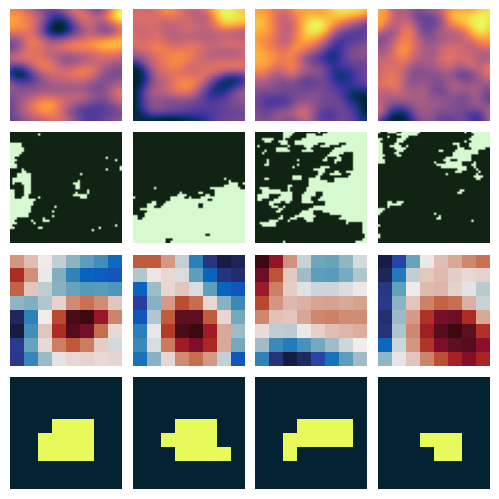

In [69]:
fig, axs = plt.subplots(4, 4)
fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=-0.55, hspace=0.1)

eddy_with_eddy = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == 1, map(lambda iv: (df_train.iloc[0]["TRAIN_LABELS"][0][iv[0]], iv[1]), enumerate(df_train.iloc[0]["EDDY"])))))
chla_with_eddy = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == 1, map(lambda iv: (df_train.iloc[0]["TRAIN_LABELS"][0][iv[0]], iv[1]), enumerate(df_train.iloc[0]["CHLA"])))))
sla_with_eddy = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == 1, map(lambda iv: (df_train.iloc[0]["TRAIN_LABELS"][0][iv[0]], iv[1]), enumerate(df_train.iloc[0]["SLA"])))))
sst_with_eddy = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == 1, map(lambda iv: (df_train.iloc[0]["TRAIN_LABELS"][0][iv[0]], iv[1]), enumerate(df_train.iloc[0]["SST"])))))

for i, ax in enumerate(axs.flat):
    match int(i / 4):
        case 0: ax.imshow(sst_with_eddy[i], cmap=cmocean.cm.thermal)
        case 1: ax.imshow(chla_with_eddy[i], cmap=cmocean.cm.algae)
        case 2: ax.imshow(sla_with_eddy[i], cmap=cmocean.cm.balance)
        case 3: ax.imshow(eddy_with_eddy[i], cmap=cmocean.cm.thermal)
    
    
    ax.axis('off')


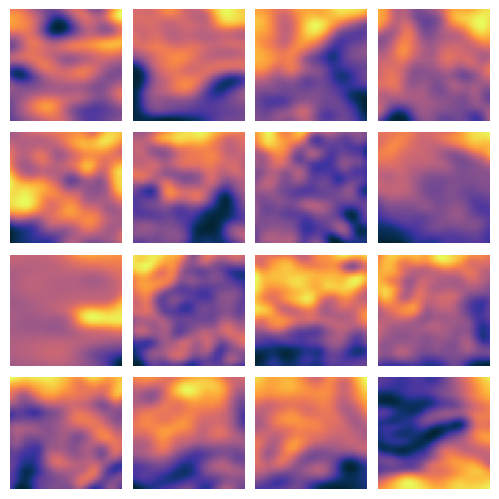

In [60]:
fig, axs = plt.subplots(4, 4)
fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=-0.55, hspace=0.1)

eddy_images = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == 1, map(lambda iv: (df_train.iloc[0]["TRAIN_LABELS"][0][iv[0]], iv[1]), enumerate(df_train.iloc[0]["SST"])))))

for i, ax in enumerate(axs.flat):
    # Select image
    image = eddy_images[i]

    # Image
    ax.imshow(image, cmap=cmocean.cm.thermal)
    ax.axis('off')


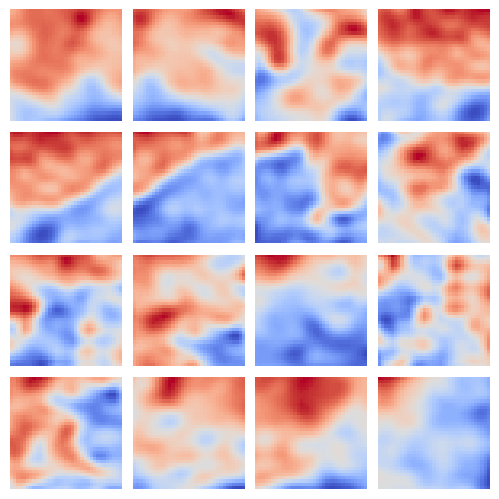

In [6]:
fig, axs = plt.subplots(4, 4)
fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=-0.55, hspace=0.1)

eddy_images = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == 0, map(lambda iv: (df_train.iloc[0]["TRAIN_LABELS"][0][iv[0]], iv[1]), enumerate(df_train.iloc[0]["SST"])))))

for i, ax in enumerate(axs.flat):
    # Select image
    image = eddy_images[i]
    
    # Image
    ax.imshow(image, cmap="coolwarm")
    ax.axis('off')


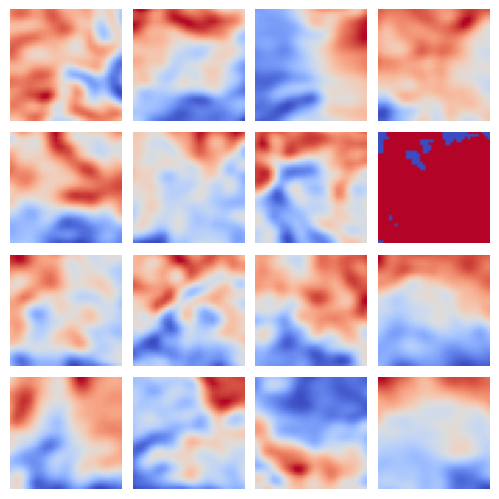

In [7]:
fig, axs = plt.subplots(4, 4)
fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=-0.55, hspace=0.1)

eddy_images = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == 2, map(lambda iv: (df_train.iloc[0]["TRAIN_LABELS"][0][iv[0]], iv[1]), enumerate(df_train.iloc[0]["SST"])))))

for i, ax in enumerate(axs.flat):
    # Select image
    image = eddy_images[i]
    
    # Image
    ax.imshow(image, cmap="coolwarm")
    ax.axis('off')


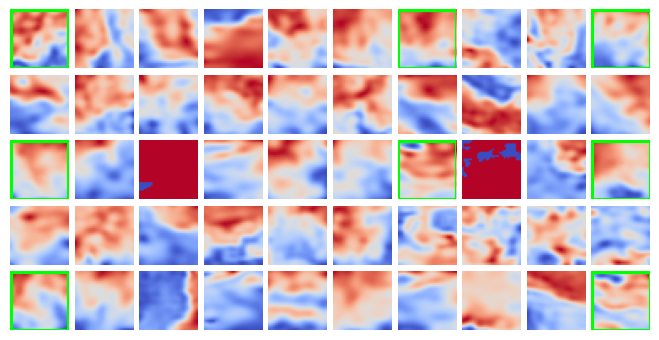

In [8]:
fig, axs = plt.subplots(5, 10)
fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.1, hspace=-.7)

random_i = [random.randint(0, len(df_train) - 1) for _ in range(0, 5)]
random_j = [random.randint(0, 50) for _ in range(0, 10)]

for i, axi in enumerate(axs):
    for j, axj in enumerate(axi):
        # Select image
        image = df_train.iloc[random_i[i]]["SST"][random_j[j]]

        # Border?
        if df_train.iloc[random_i[i]]["TRAIN_LABELS"][0][random_j[j]] == 1:
            rect = mpl.patches.Rectangle((0, 0), width=len(image), height=len(image[0]), fc="none", ec="lime", lw=3)
            axj.add_patch(rect)
        elif df_train.iloc[random_i[i]]["TRAIN_LABELS"][0][random_j[j]] == 2:
            rect = mpl.patches.Rectangle((0, 0), width=len(image), height=len(image[0]), fc="none", ec="blue", lw=3)
            axj.add_patch(rect)
        
        # Image
        axj.imshow(image, cmap="coolwarm")
        axj.axis('off')
        
        # # Text
        # if i == 0: axj.set_title(f"Nr. {j + 1}", fontsize=10)
        # if j == 0: axj.text(-0.2, 0.5, df_train.iloc[i + i_offset].name.strftime("%d.%m.%Y"), transform=axj.transAxes, va='center', ha='right')

<h1>Training, Validation, and Test Datasets</h1>

<p>
...
</p>

<h1>Exploratory Data Analysis</h1>

<p>
...
</p>

<h1>Model</h1>

<p>
...
</p>

<h1>Metrics</h1>

<p>
...
</p>

<h1>Conclusion</h1>

<p>
...
</p>

<h1>References</h1>

<p>[1] Authors. Title. Name. (Year). <a href="https://www.example.com" target="_blank">https://www.example.com/</a> (Accessed online: date)</p>

<p>[1] Dennis G Wilson, Mercator Hackathon, Simon van Gennip, and svangennip. Ocean Eddy Identification. Kaggle. (2022). <a href="https://www.kaggle.com/competitions/mercatorocean" target="_blank">https://www.kaggle.com/competitions/mercatorocean/data</a> (Accessed online: 20.04.2026)</p>